In [1]:
import os
import time
import json
import pickle
import pandas as pd
import numpy as np

from datetime import datetime
from tqdm import tqdm
from dotenv import load_dotenv
from pathlib import Path

In [2]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity

from huggingface_hub import login
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoConfig, AutoTokenizer, AutoModelForSequenceClassification
from transformers.optimization import get_linear_schedule_with_warmup
from vllm import LLM, SamplingParams
import optuna

import mlflow
from databricks.sdk import WorkspaceClient

/opt/conda/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-12-08 15:58:44.109724: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-12-08 15:58:44.124803: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-12-08 15:58:44.129377: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-08 15:58:44.143320: I tensorflow/core/platfor

INFO 12-08 15:58:45 [__init__.py:239] Automatically detected platform cuda.


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

Define path variables

In [4]:
model_id = "google/bigbird-roberta-base"
model_name = "bigbird-roberta-base"
classification_type = "classification_head"

developer_initials = "JP"

In [5]:
current_dir = Path.cwd()
env_path = current_dir.parent.parent / "conf" / "local" / ".env"
results_path = current_dir.parent.parent / "results" / "transformer"

train_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-training-large-cleaned.jsonl"
validation_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan20-authorship-verification-validation-large-cleaned.jsonl"
test_data_full_cleaned_path = current_dir.parent.parent / "data" /  "01_processed" / "pan21-authorship-verification-test-cleaned.jsonl"

run_name=f"{developer_initials}_{model_name}_{results_path}_{classification_type}"

Load environment variables
Get access to HuggingFace

In [6]:
load_dotenv(env_path)
huggingface_acess_token = os.getenv("huggingface_jp")

Connect to databricks for logging results

In [7]:
w = WorkspaceClient()   
print("Connected to:", w.config.host)

mlflow.set_tracking_uri("databricks")
mlflow.autolog()

2025/12/08 15:58:48 INFO mlflow.tracking.fluent: Autologging successfully enabled for keras.


Connected to: https://dbc-1ea3ad0e-f504.cloud.databricks.com


2025/12/08 15:58:48 INFO mlflow.tracking.fluent: Autologging successfully enabled for openai.
2025/12/08 15:58:48 WARNING mlflow.utils.autologging_utils: MLflow sklearn autologging is known to be compatible with 1.4.0 <= scikit-learn, but the installed version is 1.3.1. If you encounter errors during autologging, try upgrading / downgrading scikit-learn to a compatible version, or try upgrading MLflow.
2025/12/08 15:58:48 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2025/12/08 15:58:48 WARNING mlflow.utils.autologging_utils: MLflow statsmodels autologging is known to be compatible with 0.14.1 <= statsmodels, but the installed version is 0.14.0. If you encounter errors during autologging, try upgrading / downgrading statsmodels to a compatible version, or try upgrading MLflow.
2025/12/08 15:58:48 INFO mlflow.tracking.fluent: Autologging successfully enabled for statsmodels.
2025/12/08 15:58:49 WARNING mlflow.tracking.fluent: Exception raised while enabling 

What are GPU are the experiments run on

In [8]:
!nvidia-smi

Mon Dec  8 15:58:49 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          Off |   00000000:61:00.0 Off |                    0 |
| N/A   59C    P0             62W /  300W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [9]:
running_on_gpu = torch.cuda.is_available()
device = torch.device("cuda" if running_on_gpu else "cpu")

In [10]:
if running_on_gpu:
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_vram_gb = round(gpu_props.total_memory / (1024**3), 2)
else:
    gpu_name = "CPU"
    gpu_props = "N/A"
    gpu_vram_gb = 0

Empty the GPU from previous experiments

In [11]:
import gc
import torch
torch.cuda.empty_cache()
gc.collect()

122

In [12]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

Definition of the training constants

In [13]:
optimizer_learning_rate_range = (1e-6, 5e-5)
epochs_range = (2, 5)
batch_size = [2, 4]

weight_decay = (0.0, 0.1)
warmup_ratio = [0.0, 0.5, 0.1]
classifier_dropout = (0.0, 0.3)

classification_thresholds = [x/1000 for x in range(100, 999)]

Training dataset size for tuning

In [14]:
train_tuning_size = 19_999

#### Load training data

In [15]:
train_data_file_size = os.path.getsize(train_data_full_cleaned_path)
train_data = []

with open(train_data_full_cleaned_path, 'r') as f:
    with tqdm(total=train_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            train_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(train_data)} items.")

Loading data: 100%|██████████| 11.4G/11.4G [00:22<00:00, 510MB/s]


Successfully loaded 275801 items.


In [16]:
train_data_df = pd.DataFrame(train_data)

Prepare dataset for cosine embedding loss

In [17]:
train_data_df.head(10)

,id,pair,same
0,6b177179-72d2-5c87-ba2e-7678ae8c1db2,[Alright We looked at the crowd of wideeyed ki...,True
1,80ff51a1-8f2b-507e-bece-e0a187f26a19,[I had a rude awakening when a goblin threw so...,True
2,b6492f44-4d7b-51d2-a6c8-fdfaf62868e4,[The offer still stands She stopped breathing ...,True
3,c502df34-8c2e-5a86-9555-cdcf0b03f189,[Yeah Just pretend youve put on the record Tak...,True
4,653cfc2d-5e82-5afa-87b1-c5b793441483,[Paloma just went aww like it could actually h...,True
5,7284fa07-32de-5ab8-a5b3-5b040bb59898,"[Good, honey, how are you Oh, Im Dealing with ...",True
6,ec4ca49c-5975-5b25-8f9b-bfc774775ce2,[Something wrong he ventures timidly Ishouldnt...,True
7,7b312e06-d0d3-503b-ab52-997f99dd29bb,"[Down, down they tumble down the hole, filled ...",True
8,2618e80d-1150-5d31-90ff-818d28e40724,"[Well, why dont you hold onto it if it bothers...",True
9,531e63a7-5db2-5ba8-9737-ad2ceab0265a,"[Thank you, he whispers, and downs it in one s...",True


#### Create a subset of training data for finetuning

In [18]:
train_tuning_data_df = train_data_df.sample(n=train_tuning_size, random_state=42)
train_tuning_data_df = train_tuning_data_df.reset_index(drop=True)
train_tuning_data_df.head()

,id,pair,same
0,b2ae0880-dfc8-5348-becb-5b9cbb331e3c,[He hated it when it rain during nights that h...,True
1,1ba2349a-7342-5829-920b-64038c9fe815,[smiled Buona notte Ti amo Danny whispered Ti ...,False
2,96dc6b60-1ad6-56b0-b035-00e6f057bedb,[Haruki I said trailling off He moaned and beg...,False
3,431f2e19-76ab-5524-b2b2-93e86ffdb6f8,[wouldnt have mattered Its legendary here You ...,True
4,50b24ce9-e2b0-5687-8f5d-cbe49e76ce0c,[Authors Note I felt like the last two minutes...,True


#### Load validation data

In [19]:
val_data_file_size = os.path.getsize(validation_data_full_cleaned_path)
val_data = []

with open(validation_data_full_cleaned_path, 'r') as f:
    with tqdm(total=val_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            val_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(val_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:01<00:00, 502MB/s] 


Successfully loaded 19999 items.


In [20]:
val_data_df = pd.DataFrame(val_data)

#### Load testing data

In [21]:
test_data_file_size = os.path.getsize(test_data_full_cleaned_path)
test_data = []

with open(test_data_full_cleaned_path, 'r') as f:
    with tqdm(total=test_data_file_size, desc="Loading data", unit='B', unit_scale=True) as pbar:
        for line in f:
            test_data.append(json.loads(line))
            pbar.update(len(line.encode('utf-8')))

print(f"\nSuccessfully loaded {len(test_data)} items.")

Loading data: 100%|██████████| 826M/826M [00:01<00:00, 536MB/s] 


Successfully loaded 19999 items.


In [22]:
test_data_df = pd.DataFrame(test_data)

In [23]:
train_tuning_data_df = train_tuning_data_df.head(10) #REMOVEE
train_data_df = train_data_df.head(10) #REMOVEE
val_data_df = val_data_df.head(10)  #REMOVEE
test_data_df = test_data_df.head(10)  #REMOVEE

# Set up model

Log in to huggingface

In [24]:
login(huggingface_acess_token)

Load the pre-trained model

In [25]:
tokenizer = AutoTokenizer.from_pretrained(model_id)
config = AutoConfig.from_pretrained(model_id)

# Set up training functions

Helper class for pytorch

In [26]:
class PairDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.loc[idx]
        text1 = row["pair"][0]
        text2 = row["pair"][1]
        label = int(row["same"])
        return text1, text2, label

In [27]:
def evaluate_f1_pruning(model, val_data_df):
    model.eval()
    
    predictions = [] 
    labels = []
    
    with torch.no_grad():
        for i in val_data_df.index:
            text1 = val_data_df.loc[i, "pair"][0]
            text2 = val_data_df.loc[i, "pair"][1]
            
            label = int(val_data_df.loc[i, "same"])
            
            enc = tokenizer(
                text1,
                text2,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=4096
            ).to(device)
            
            logits = model(**enc).logits
            prediction = torch.argmax(logits, dim=-1).item()
            
            predictions.append(prediction)
            labels.append(label)
            
    calculate_f1 = f1_score(labels, predictions, average="weighted")
    model.train()
    
    return calculate_f1

Model training function

In [28]:
def train_classifier(model, df, optimizer, epochs, batch_size, warmup_ratio, val_data_df, trial=None):
    ds = PairDataset(df)
    dataloader = DataLoader(ds, shuffle=True, batch_size=batch_size)

    total_steps = len(dataloader) * epochs
    warmup_steps = int(total_steps * warmup_ratio)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )
    
    model.train()
    if trial is not None:
        print(f"Starting optuna trial #{trial.number + 1} 🐻")

    best_f1 = -1

    for epoch in range(epochs):
        total_loss = 0

        for text1, text2, labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):

            labels = labels.to(device)

            enc = tokenizer(
                list(text1),
                list(text2),
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=4096
            ).to(device)

            outputs = model(**enc, labels=labels)
            loss = outputs.loss
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            avg_loss = total_loss / len(dataloader)
        
        if val_data_df is not None:
            pruning_f1 = evaluate_f1_pruning(model, val_data_df)

            if trial is not None:
                trial.report(pruning_f1, epoch)
                if trial.should_prune():
                    print(f"Trial {trial.number + 1} successfully pruned.")
                    raise optuna.TrialPruned()

            best_f1 = max(best_f1, pruning_f1)
            
        if trial is not None:
            print(f"Optuna trial #{trial.number + 1} Epoch {epoch+1}/{epochs} complete | Loss: {avg_loss:.4f}")
        else:
            print(f"Epoch {epoch+1}/{epochs} complete | Loss: {avg_loss:.4f}")

    return model, best_f1

# Set up evaluation functions

Evaluate model function

In [29]:
def compute_classifier_scores(test_data_df, model):
    start_time = time.time()
    verification_results = []
    model.eval()

    with torch.no_grad():
        for i in tqdm(test_data_df.index, desc="Testing model"):
            
            resulting_df_row = {}
            resulting_df_row['id']  = test_data_df.loc[i, 'id']
            resulting_df_row['actual_result'] = test_data_df.loc[i, 'same']
            
            text1 = test_data_df.loc[i, 'pair'][0]
            text2 = test_data_df.loc[i, 'pair'][1]

            enc = tokenizer(
                text1,
                text2,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=4096
            ).to(device)

            logits = model(**enc).logits
            probs = F.softmax(logits, dim=-1)
            prob_same = probs[0, 1].item()

            resulting_df_row["propability_same_author"] = prob_same
            verification_results.append(resulting_df_row)

    result_df = pd.DataFrame(verification_results)
    print("--- Execution Time: %s seconds ---" % round(time.time() - start_time, 2))

    return result_df

Evaluation function

In [30]:
def evaluate_results(y_true, y_pred, average='binary'):
    accuracy = round(accuracy_score(y_true, y_pred)*100, 2)
    precision = round(precision_score(y_true, y_pred, average=average, zero_division=0)*100, 2)
    recall = round(recall_score(y_true, y_pred, average=average)*100, 2)
    f1 = round(f1_score(y_true, y_pred, average=average)*100, 2)
    return accuracy, precision, recall, f1

Optimal threshold search

In [31]:
def evaluate_classification_thresholds(result_df, classification_thresholds):
    results = []
    y_embeddings = result_df['propability_same_author']
    y_true = result_df['actual_result']
    for threshold in classification_thresholds:
        y_pred = (result_df["propability_same_author"] >= threshold).astype(int)
        accuracy, precision, recall, f1 = evaluate_results(y_true, y_pred)
        results.append({
            "propability_same_author": threshold,
            "accuracy" : accuracy,
            "precision" : precision,
            "recall" : recall,
            "f1" : f1
        })
    return pd.DataFrame(results)

Create histogram of F1 score for different thresholds

In [32]:
def plot_f1_vs_threshold(results_df):
    plt.figure(figsize=(9, 5))
    plt.plot(results_df["propability_same_author"], results_df["f1"], linewidth=2)
    plt.xlabel("Propability the text belongs to the same author")
    plt.ylabel("F1 Score")
    plt.title("F1 Score vs Classification Threshold")
    plt.grid(True)
    plt.tight_layout()
    return plt.gcf()

Create the confusion matrix

In [33]:
def create_confusion_matrix(y_true, y_pred, labels=[False, True]):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    
    cm_fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, 
                fmt='d', 
                cmap='Blues',
                xticklabels=labels, 
                yticklabels=labels, 
                ax=ax,
                cbar=False)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix: {model_id}')
    return cm_fig

# Hyperparameter optimization

Objective function - to train and evaluate all combinations of the model and log the results

In [34]:
def objective(trial):
    top_f1_trial = -1
    
    lr = trial.suggest_float("lr", optimizer_learning_rate_range[0], optimizer_learning_rate_range[1], log=True)
    epochs = trial.suggest_int("epochs", epochs_range[0], epochs_range[1])
    batch_s = trial.suggest_categorical("batch_size", batch_size)
    w_decay = trial.suggest_float("weight_decay", weight_decay[0], weight_decay[1])
    wu_ratio = trial.suggest_categorical("warmup_ratio", warmup_ratio)
    cl_dropout = trial.suggest_float("classifier_dropout", classifier_dropout[0], classifier_dropout[1])

    model = AutoModelForSequenceClassification.from_pretrained(
    model_id,
    num_labels=2,                # 0 = different author, 1 = same author
    problem_type="single_label_classification" #not multiclass or regression
    )
    config.hidden_dropout = classifier_dropout
    config.attention_dropout = classifier_dropout

    model = model.to(device)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=w_decay)

    trained_model = train_classifier(
        model=model,
        df=train_tuning_data_df ,
        optimizer=optimizer,
        epochs=epochs,
        batch_size=batch_s,
        warmup_ratio=wu_ratio,
        trial=trial,
        val_data_df=val_data_df
    )

    print(f"Training for the optuna trial {trial.number} complete --- testing the model  \n")
    result_df = compute_classifier_scores(val_data_df, model)
    
    print(f"Evaluating classification thresholds \n")
    threshold_results_df = evaluate_classification_thresholds(result_df, classification_thresholds)
    
    top_row = threshold_results_df.sort_values("f1", ascending=False).iloc[0]
    top_propability_same_author = top_row["propability_same_author"]
    top_f1 = top_row["f1"]
    top_accuracy = top_row["accuracy"]
    top_precision = top_row["precision"]
    top_recall = top_row["recall"]

    print(f"Logging results \n")
    print(f"Top threshold: {top_propability_same_author}\n")
    print(f"Top f1: {top_f1}\n")
    print(f"Top accuracy: { top_accuracy}\n")
    print(f"Top precision: {top_precision}\n")
    print(f"Top recall: {top_recall}\n")

    print(f"Used hyperparameters \n")
    print(f"optimizer_learning_rate: {lr}\n")
    print(f"weight_decay: {w_decay}\n")
    print(f"warmup_ratio: {wu_ratio}\n")
    print(f"classifier_dropout: {cl_dropout}\n")
    
    trial_results[trial.number] = {
    "metrics": {
        "top_probability_same_author": top_propability_same_author,
        "top_f1": top_f1,
        "top_accuracy": top_accuracy,
        "top_precision": top_precision,
        "top_recall": top_recall
    },
    "hyperparameters": {
        "learning_rate": lr,
        "weight_decay": w_decay,
        "warmup_ratio": wu_ratio,
        "classifier_dropout": cl_dropout,
        "epochs": epochs,
        "batch_size": batch_s,
        }
    }
    
    del model
    gc.collect()
    torch.cuda.empty_cache()
    
    return top_f1   

Set up the study

In [35]:
date_str = datetime.now().strftime("%Y%m%d_%H%M")
optuna_study_path = current_dir.parent.parent / "data" / "02_models" / f"{developer_initials}_{date_str}_{model_name}_{classification_type}_optuna.db"
str_optuna_study_path = f"sqlite:///{optuna_study_path.resolve()}"
trial_results = {}

In [36]:
pruner = optuna.pruners.SuccessiveHalvingPruner(
    min_resource=1,          # allow at least 1 epoch
    reduction_factor=3,      # prune ~66% of trials each round
    min_early_stopping_rate=0
)


study = optuna.create_study(
    study_name="authorship_verification_longformer",
    storage=str_optuna_study_path,
    direction="maximize",
    pruner=pruner,
    load_if_exists=True
)

[I 2025-12-08 15:59:17,641] A new study created in RDB with name: authorship_verification_longformer


In [37]:
study.optimize(objective, n_trials=10)

Some weights of BigBirdForSequenceClassification were not initialized from the model checkpoint at google/bigbird-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting optuna trial #1 🐻


Epoch 1/4: 100%|██████████| 5/5 [00:04<00:00,  1.24it/s]


Optuna trial #1 Epoch 1/4 complete | Loss: 0.6813


Epoch 2/4: 100%|██████████| 5/5 [00:03<00:00,  1.33it/s]


...

Optuna trial #10 Epoch 2/2 complete | Loss: 0.6393
Training for the optuna trial 9 complete --- testing the model  



Testing model: 100%|██████████| 10/10 [00:01<00:00,  7.63it/s]


--- Execution Time: 1.31 seconds ---
Evaluating classification thresholds 



[I 2025-12-08 16:03:34,943] Trial 9 finished with value: 100.0 and parameters: {'lr': 2.1435779834705194e-05, 'epochs': 2, 'batch_size': 2, 'weight_decay': 0.07796363082407304, 'warmup_ratio': 0.0, 'classifier_dropout': 0.09821381296278285}. Best is trial 1 with value: 100.0.


Logging results 

Top threshold: 0.549

Top f1: 100.0

Top accuracy: 100.0

Top precision: 100.0

Top recall: 100.0

Used hyperparameters 

optimizer_learning_rate: 2.1435779834705194e-05

weight_decay: 0.07796363082407304

warmup_ratio: 0.0

classifier_dropout: 0.09821381296278285



Save the best model weights

In [38]:
best_trial = study.best_trial
best_params = best_trial.params

date_str = datetime.now().strftime("%Y%m%d_%H%M")

finetuned_model_best_params = current_dir.parent.parent / "data" / "02_models" / f"{developer_initials}_{date_str}_{model_name}_{classification_type}_best_parameters.json"
finetuned_model_path = current_dir.parent.parent / "data" / "02_models" / f"{developer_initials}_{date_str}_{model_name}_{classification_type}_best_model"

In [39]:
with open(finetuned_model_best_params, "w") as f:
    json.dump(best_params, f, indent=4)

# Train the final model

In [40]:
with open(finetuned_model_best_params, "r") as f:
    best_params = json.load(f)

In [41]:
lr = best_params["lr"]
w_decay = best_params["weight_decay"]
wu_ratio = best_params["warmup_ratio"]
cl_dropout = best_params["classifier_dropout"]
epochs = best_params["epochs"]
batch_s = best_params["batch_size"]

Some weights of BigBirdForSequenceClassification were not initialized from the model checkpoint at google/bigbird-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Starting full training  



Epoch 1/4: 100%|██████████| 3/3 [00:03<00:00,  1.17s/it]


Epoch 1/4 complete | Loss: 0.7910


Epoch 2/4: 100%|██████████| 3/3 [00:03<00:00,  1.18s/it]


...

Epoch 3/4 complete | Loss: 0.5142


Epoch 4/4: 100%|██████████| 3/3 [00:03<00:00,  1.17s/it]


Epoch 4/4 complete | Loss: 0.4600


Testing model: 100%|██████████| 10/10 [00:01<00:00,  7.66it/s]


--- Execution Time: 1.31 seconds ---
Evaluating classification thresholds 

Top threshold: 0.1

Top f1: 82.35

Top accuracy: 70.0

Top precision: 70.0

Top recall: 100.0



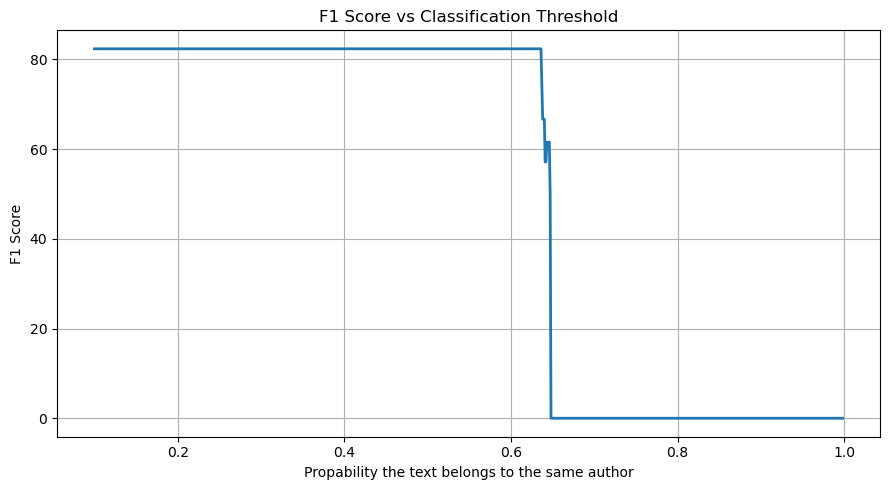

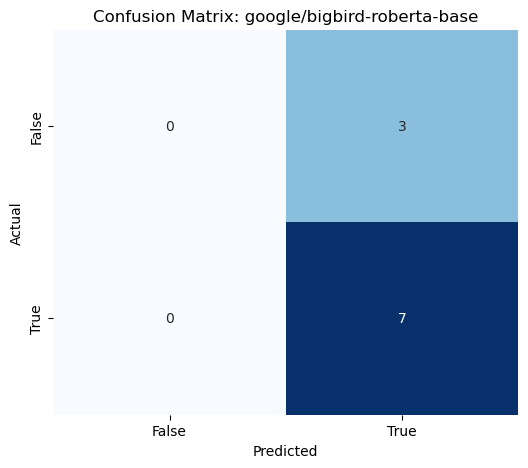

In [43]:
model = AutoModelForSequenceClassification.from_pretrained(
model_id,
num_labels=2,                # 0 = different author, 1 = same author
problem_type="single_label_classification" #not multiclass or regression
)
config.hidden_dropout = cl_dropout
config.attention_dropout = cl_dropout

model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=w_decay)

print(f"Starting full training  \n")
trained_model = train_classifier(
    model=model,
    df=train_data_df ,
    optimizer=optimizer,
    epochs=epochs,
    batch_size=batch_s,
    warmup_ratio=wu_ratio,
    val_data_df=None
)

result_df = compute_classifier_scores(test_data_df, model)

print(f"Evaluating classification thresholds \n")
threshold_results_df = evaluate_classification_thresholds(result_df, classification_thresholds)

top_row = threshold_results_df.sort_values("f1", ascending=False).iloc[0]
top_propability_same_author = top_row["propability_same_author"]
top_f1 = top_row["f1"]
top_accuracy = top_row["accuracy"]
top_precision = top_row["precision"]
top_recall = top_row["recall"]

f1_threshold_histogram_fig = plot_f1_vs_threshold(threshold_results_df)
    
y_true = result_df["actual_result"]
y_pred = (result_df["propability_same_author"] >= top_propability_same_author).astype(int)
cm_fig = create_confusion_matrix(y_true, y_pred)

print(f"Top threshold: {top_propability_same_author}\n")
print(f"Top f1: {top_f1}\n")
print(f"Top accuracy: { top_accuracy}\n")
print(f"Top precision: {top_precision}\n")
print(f"Top recall: {top_recall}\n")

Save the model

In [44]:
model.to("cpu")
model.save_pretrained(finetuned_model_path)

Log the results

In [45]:
date_str = datetime.now().strftime("%Y%m%d_%H%M")
mlflow.set_experiment("/Users/jiripokorny455@gmail.com/JP_authorship_verification_dt")
with mlflow.start_run(run_name=f"{developer_initials}_{date_str}_{model_name}_results_{classification_type}"):
    mlflow.log_param("gpu_name", gpu_name)
    mlflow.log_param("gpu_vram_gb", gpu_vram_gb)
    
    mlflow.log_param("model_id ", model_id )
    mlflow.log_param("classification_type", classification_type)
    mlflow.log_table(data=trial_results, artifact_file="trial_results.json")

    
    mlflow.log_param("final_optimizer_learning_rate", lr)
    mlflow.log_param("final_epochs", epochs)
    mlflow.log_param("final_batch_size", batch_s)
    mlflow.log_param("final_weight_decay", w_decay)
    mlflow.log_param("final_warmup_ratio", wu_ratio)
    mlflow.log_param("final_classifier_dropout", cl_dropout)

    mlflow.log_param("classification_score_thresholds", classification_thresholds)
    mlflow.log_table(data=result_df, artifact_file="final_classifier_score_results.json")
    mlflow.log_table(data=threshold_results_df, artifact_file="final_results_for_different_thresholds.json")

    mlflow.log_metric("top_propability_same_author", top_propability_same_author)
    mlflow.log_metric("top_result_accuracy", top_accuracy)
    mlflow.log_metric("top_precision", top_precision)
    mlflow.log_metric("top_recall", top_recall)
    mlflow.log_metric("top_f1", top_f1)

    mlflow.log_figure(f1_threshold_histogram_fig, "final_f1_results_threshold_histogram.png")
    mlflow.log_figure(cm_fig, "final_confusion_matrix.png")

🏃 View run JP_20251208_1615_bigbird-roberta-base_results_classification_head at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040/runs/9317557941c445b4b0cee53176c0f258
🧪 View experiment at: https://dbc-1ea3ad0e-f504.cloud.databricks.com/ml/experiments/134079680834040
